[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nisheshgogia/vorithm-interview-questions-solutions/blob/main/Python/strings/strings.ipynb)

# **STRINGS**

## **1. Reverse a String**
# (**Difficulty: 🟢 Low**)


Problem
Given a string s, return the reversed version of the string.


```
Examples

Example 1
Input: s = "hello"
Output: "olleh"
```
```
Example 2
Input: s = "OpenAI"
Output: "IAnepO"

In [ ]:
#Brute Force Approach
def reverse_string_brute(s):
    result = ""
    for i in range(len(s) - 1, -1, -1):  # loop runs n times backwards
        result += s[i]                     # string concatenation each step
    return result

print(reverse_string_brute("hello"))   # Output: olleh
print(reverse_string_brute("OpenAI"))  # Output: IAnepO

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n) : always loops through all n characters, no early exit
# avg   → O(n) : one pass through n characters each doing O(1) index access
# worst → O(n) : string of length n → loop always runs exactly n times
# space → O(n) : result string grows to hold all n characters

#best time complexity    - O(n)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(n)

olleh
IAnepO


In [ ]:
#Optimized Approach (Two Pointer)
def reverse_string_optimized(s):
    s = list(s)                      # convert to list for O(1) index swap
    left, right = 0, len(s) - 1     # two pointers at both ends
    while left < right:              # runs n/2 times
        s[left], s[right] = s[right], s[left]  # O(1) swap
        left += 1
        right -= 1
    return "".join(s)                # O(n) join at end

print(reverse_string_optimized("hello"))   # Output: olleh
print(reverse_string_optimized("OpenAI"))  # Output: IAnepO

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n) : even single char still converts to list + joins = O(n)
# avg   → O(n) : loop runs n/2 times with O(1) swaps → n/2 = O(n)
# worst → O(n) : long string → n/2 swaps + O(n) join, dominated by O(n)
# space → O(n) : list(s) creates a new list of n characters

#best time complexity    - O(n)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(n)

olleh
IAnepO


# 2. Check if a String is a Palindrom   (Difficulty: 🟢 Low)

Given a string s, return true if the string is a palindrome, otherwise return false.

A palindrome reads the same forward and backward.

Examples
```
Example 1
Input: s = "madam"
Output: true
```
```
Example 2
Input: s = "hello"
Output: false


In [ ]:
#Brute Force Approach
def is_palindrome_brute(s):
    reversed_s = ""
    for i in range(len(s) - 1, -1, -1):  # full reverse pass O(n)
        reversed_s += s[i]
    return s == reversed_s                # O(n) comparison

print(is_palindrome_brute("madam"))  # Output: True
print(is_palindrome_brute("hello"))  # Output: False

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n) : always builds full reversed string before comparing
# avg   → O(n) : reverse loop n steps + final comparison n steps = 2n = O(n)
# worst → O(n) : long palindrome → reverse all n chars + compare all n = O(n)
# space → O(n) : reversed_s stores a full copy of the string

#best time complexity    - O(n)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(n)

True
False


In [ ]:
#Optimized Approach (Two Pointer)
def is_palindrome_optimized(s):
    left, right = 0, len(s) - 1   # pointers at both ends
    while left < right:            # runs at most n/2 times
        if s[left] != s[right]:    # mismatch → early exit
            return False
        left += 1
        right -= 1
    return True

print(is_palindrome_optimized("madam"))  # Output: True
print(is_palindrome_optimized("hello"))  # Output: False

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(1) : first and last characters mismatch → return False immediately
# avg   → O(n) : mismatch found somewhere in middle → ~n/2 comparisons
# worst → O(n) : full palindrome like "abcba" → all n/2 pairs checked
# space → O(1) : only two integer pointers, no extra string storage

#best time complexity    - O(1)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(1)

True
False


# 3.Validate Balanced Brackets (Difficulty: 🟡 Medium)


Given a string s containing only the characters:

(, ), {, }, [, ]

Return true if the brackets are balanced, otherwise return false.

A string is valid if:

Every opening bracket has a matching closing bracket.

Brackets close in the correct order.

Examples
```
Example 1
Input: s = "()[]{}"
Output: true
```
```
Example 2
Input: s = "(]"
Output: false

In [ ]:
#Brute Force Approach
def is_balanced_brute(s):
    while "()" in s or "{}" in s or "[]" in s:  # scan for matching pairs
        s = s.replace("()", "").replace("{}", "").replace("[]", "")
    return s == ""

print(is_balanced_brute("()[]{}"))  # Output: True
print(is_balanced_brute("(]"))      # Output: False

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n) : single pair like "()" → one while iteration, one replace = O(n)
# avg   → O(n^2): each while iteration scans entire string O(n) to find pairs
#                 and up to n/2 iterations needed to remove all pairs = O(n^2)
# worst → O(n^2): deeply nested like "(((...)))" → n/2 passes × O(n) scan each
# space → O(n) : each replace creates a new string of shrinking size up to O(n)

#best time complexity    - O(n)
#average time complexity - O(n^2)
#worst time complexity   - O(n^2)
#space complexity        - O(n)

True
False


In [ ]:
#Optimized Approach (Stack)
def is_balanced_optimized(s):
    stack = []
    mapping = {')': '(', '}': '{', ']': '['}  # closing → opening map
    for char in s:                             # single pass O(n)
        if char in mapping:                    # closing bracket
            top = stack.pop() if stack else '#'
            if mapping[char] != top:           # mismatch → invalid
                return False
        else:
            stack.append(char)                 # opening bracket pushed
    return not stack                           # valid only if stack empty

print(is_balanced_optimized("()[]{}"))  # Output: True
print(is_balanced_optimized("(]"))      # Output: False

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n) : even "(]" still scans all chars before returning False
#                no early exit at character level since we process each char once
# avg   → O(n) : each character pushed/popped at most once → 2n ops = O(n)
# worst → O(n) : all opening brackets "(((" → all pushed, then empty check O(1)
# space → O(n) : stack can hold up to n/2 opening brackets in worst case

#best time complexity    - O(n)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(n)

True
False


# 4.Count Vowels in a String (Difficulty: 🟢 Low)


Given a string s, return the number of vowels (a, e, i, o, u) present in the string.

Examples
```
Example 1
Input: s = "hello"
Output: 2
```
```
Example 2
Input: s = "xyz"
Output: 0


In [ ]:
#Brute Force Approach
def count_vowels_brute(s):
    count = 0
    vowels = ['a', 'e', 'i', 'o', 'u']  # list lookup is O(5) = O(1)
    for char in s.lower():               # loop runs n times
        if char in vowels:               # scans list of 5 items = O(1)
            count += 1
    return count

print(count_vowels_brute("hello"))  # Output: 2
print(count_vowels_brute("xyz"))    # Output: 0

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n) : no vowels in string → still scans all n characters
# avg   → O(n) : each character checked against 5-item list = O(5) = O(1)
#                total = n × O(1) = O(n)
# worst → O(n) : all vowels → same n iterations, count just increments more
# space → O(1) : vowels list is fixed size 5, only count variable added

#best time complexity    - O(n)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(1)

2
0


In [ ]:
#Optimized Approach (Set Lookup)
def count_vowels_optimized(s):
    vowels = set("aeiouAEIOU")          # set gives O(1) average lookup
    return sum(1 for char in s if char in vowels)
    # generator avoids building intermediate list
    # sum() accumulates in single pass

print(count_vowels_optimized("hello"))  # Output: 2
print(count_vowels_optimized("xyz"))    # Output: 0

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n) : still iterates all n characters even if none are vowels
# avg   → O(n) : set lookup O(1) per char × n chars = O(n) total
# worst → O(n) : all characters vowels → n checks each O(1) = O(n)
# space → O(1) : vowels set is fixed 10 items regardless of input size

#best time complexity    - O(n)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(1)

2
0


# 5.Remove Duplicate Characters (Difficulty: 🟢 Low)

Given a string s, return a new string with all duplicate characters removed while keeping the first occurrence.

Examples
```
Example 1
Input: s = "banana"
Output: "ban"

```
````
Example 2
Input: s = "aabbcc"
Output: "abc"

In [ ]:
#Brute Force Approach
def remove_duplicates_brute(s):
    result = ""
    for char in s:              # outer loop: n iterations
        if char not in result:  # 'in' scans result string → O(n) each time
            result += char
    return result

print(remove_duplicates_brute("banana"))  # Output: ban
print(remove_duplicates_brute("aabbcc"))  # Output: abc

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n)   : single unique character repeated → result stays length 1,
#                  'in result' is always O(1) → n × O(1) = O(n)
# avg   → O(n^2) : result grows as new chars found → average scan length = n/2
#                  n iterations × O(n/2) scan = O(n^2)
# worst → O(n^2) : all unique characters → result grows to n,
#                  last char check scans n-1 → total n*(n-1)/2 = O(n^2)
# space → O(n)   : result string stores up to n unique characters

#best time complexity    - O(n)
#average time complexity - O(n^2)
#worst time complexity   - O(n^2)
#space complexity        - O(n)

ban
abc


In [ ]:
#Optimized Approach (Dict for O(1) lookup)
def remove_duplicates_optimized(s):
    seen = {}          # hash dict: O(1) average lookup and insert
    result = []        # list for efficient appending
    for char in s:     # single pass O(n)
        if char not in seen:        # O(1) hash lookup
            seen[char] = True
            result.append(char)     # O(1) append
    return "".join(result)          # O(n) join at end

print(remove_duplicates_optimized("banana"))  # Output: ban
print(remove_duplicates_optimized("aabbcc"))  # Output: abc

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n) : all same char → seen hit every time after first, still n loops
# avg   → O(n) : each char: O(1) hash check + O(1) append → n × O(1) = O(n)
# worst → O(n) : all unique → all n chars added to seen and result, still O(n)
# space → O(n) : seen dict + result list together hold up to n unique chars

#best time complexity    - O(n)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(n)

ban
abc


# 6.Check if Two Strings are Anagrams (Difficulty: 🟢 Low)

Given two strings s and t, return true if they are anagrams, otherwise return false.

Two strings are anagrams if they contain the same characters in the same frequency.

Examples
```
Example 1
Input: s = "listen", t = "silent"
Output: true

```
```
Example 2
Input: s = "hello", t = "world"
Output: false


In [ ]:
#Brute Force Approach
def are_anagrams_brute(s, t):
    if len(s) != len(t):
        return False
    return sorted(s) == sorted(t)   # sort both and compare

print(are_anagrams_brute("listen", "silent"))  # Output: True
print(are_anagrams_brute("hello", "world"))    # Output: False

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n log n) : even if first chars differ after sort, sort itself
#                      costs O(n log n) before comparison can happen
# avg   → O(n log n) : Python's Timsort on n chars = O(n log n) for both strings
#                      final comparison O(n) is dominated by sort cost
# worst → O(n log n) : fully sorted input → Timsort still O(n log n)
# space → O(n)       : sorted() creates new list of n characters for each string

#best time complexity    - O(n log n)
#average time complexity - O(n log n)
#worst time complexity   - O(n log n)
#space complexity        - O(n)

True
False


In [ ]:
#Optimized Approach (Frequency HashMap)
def are_anagrams_optimized(s, t):
    if len(s) != len(t):
        return False
    count = {}
    for c in s:                              # first pass: build freq map O(n)
        count[c] = count.get(c, 0) + 1
    for c in t:                              # second pass: decrement O(n)
        if c not in count or count[c] == 0:
            return False
        count[c] -= 1
    return True

print(are_anagrams_optimized("listen", "silent"))  # Output: True
print(are_anagrams_optimized("hello", "world"))    # Output: False

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n) : first char of t not in count → return False after 1 check
#                but first loop over s still runs n → total O(n)
# avg   → O(n) : two passes of n each with O(1) hash ops = 2n = O(n)
# worst → O(n) : strings are anagrams → both full passes complete = O(n)
# space → O(1) : count dict has at most 26 keys (lowercase letters)
#                fixed size regardless of input length → O(1)

#best time complexity    - O(n)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(1)

True
False


# 7.Find First Non-Repeating Character (Return Char)  (Difficulty: 🟢 Low)

Given a string s, return the first character that does not repeat.
If none exists, return "None".

Examples
```
Example 1
Input: s = "aabbcdd"
Output: "c"
```
```
Example 2
Input: s = "aabb"
Output: None

In [ ]:
#Brute Force Approach
def first_non_repeating_brute(s):
    for i in range(len(s)):         # outer loop: n iterations
        is_unique = True
        for j in range(len(s)):     # inner loop: n iterations each
            if i != j and s[i] == s[j]:
                is_unique = False
                break               # early exit inner loop on duplicate found
        if is_unique:
            return s[i]             # first unique char found
    return None

print(first_non_repeating_brute("aabbcdd"))  # Output: c
print(first_non_repeating_brute("aabb"))     # Output: None

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n)   : first character is unique → inner loop scans n to confirm,
#                  returns immediately → just one outer + one inner = O(n)
# avg   → O(n^2) : unique char found halfway → n/2 outer × n inner = O(n^2)
# worst → O(n^2) : no unique char or unique char at end → full n×n loops
# space → O(1)   : only boolean is_unique and loop indices, no extra structure

#best time complexity    - O(n)
#average time complexity - O(n^2)
#worst time complexity   - O(n^2)
#space complexity        - O(1)

c
None


In [ ]:
#Optimized Approach (Ordered HashMap)
def first_non_repeating_optimized(s):
    count = {}
    for char in s:                       # first pass: count frequencies O(n)
        count[char] = count.get(char, 0) + 1
    for char in s:                       # second pass: find first with count=1
        if count[char] == 1:
            return char                  # O(1) lookup per char
    return None

print(first_non_repeating_optimized("aabbcdd"))  # Output: c
print(first_non_repeating_optimized("aabb"))     # Output: None

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n) : first pass always runs n steps to build count map
#                even if answer is first char, we need full frequency data first
# avg   → O(n) : two passes of n with O(1) hash ops each = 2n = O(n)
# worst → O(n) : no unique char → both full passes complete without early return
# space → O(1) : at most 26 keys in count dict for lowercase letters

#best time complexity    - O(n)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(1)


c
None


# 8 . Count Words in a Sentence  (Difficulty: 🟢 Low)

Given a sentence s, return the number of words in it.

Words are separated by spaces.

Examples
```
Example 1
Input: s = "I love Python"
Output: 3
```
```
Example 2
Input: s = "Hello"
Output: 1

In [ ]:
#Brute Force Approach
def count_words_brute(s):
    count = 0
    in_word = False
    for char in s:              # single pass through all n characters
        if char != ' ' and not in_word:   # entering a new word
            in_word = True
            count += 1
        elif char == ' ':       # space resets word tracking
            in_word = False
    return count

print(count_words_brute("I love Python"))  # Output: 3
print(count_words_brute("Hello"))          # Output: 1

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n) : single word or all spaces → still scans all n characters
# avg   → O(n) : each character checked with O(1) condition → n × O(1) = O(n)
# worst → O(n) : n words each 1 char → scans all n, toggles in_word n times
# space → O(1) : only two variables (count, in_word), no string storage

#best time complexity    - O(n)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(1)


3
1


In [ ]:
#Optimized Approach (split())
def count_words_optimized(s):
    return len(s.split())
    # split() handles multiple spaces, leading/trailing spaces automatically
    # internally does one pass to split → O(n)
    # len() on resulting list → O(1)

print(count_words_optimized("I love Python"))  # Output: 3
print(count_words_optimized("Hello"))          # Output: 1

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n) : even single word → split() still scans full string
# avg   → O(n) : split() does one linear pass through n characters
# worst → O(n) : n single-char words → split produces n-item list in O(n)
# space → O(n) : split() creates list of word strings totaling n characters

#best time complexity    - O(n)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(n)

3
1


# 9.Longest Common Prefix (Difficulty: 🟡 Medium)

Given a list of strings, return the longest common prefix shared among them.
If no prefix exists, return an empty string.

Examples
```
Example 1
Input: strs = ["flower","flow","flight"]
Output: "fl"
```
```
Example 2
Input: strs = ["dog","racecar","car"]
Output: ""

In [ ]:
#Brute Force Approach
def longest_common_prefix_brute(strs):
    if not strs:
        return ""
    prefix = strs[0]                        # start with first string
    for s in strs[1:]:                      # compare with each remaining string
        new_prefix = ""
        for i in range(min(len(prefix), len(s))):  # char by char match
            if prefix[i] == s[i]:
                new_prefix += prefix[i]
            else:
                break                       # stop at first mismatch
        prefix = new_prefix
    return prefix

print(longest_common_prefix_brute(["flower","flow","flight"]))  # Output: fl
print(longest_common_prefix_brute(["dog","racecar","car"]))     # Output: ""

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n)   : first string has no prefix match with second →
#                  prefix becomes "" early, remaining strings skip inner loop
# avg   → O(n*m) : n = number of strings, m = average string length
#                  outer loop n-1 times × inner loop up to m = O(n*m)
# worst → O(n*m) : all strings identical → inner loop runs full m for each of n
# space → O(m)   : new_prefix and prefix store up to m characters

#best time complexity    - O(n)
#average time complexity - O(n * m)
#worst time complexity   - O(n * m)
#space complexity        - O(m)

fl



In [ ]:
#Optimized Approach (Vertical Scanning)
def longest_common_prefix_optimized(strs):
    if not strs:
        return ""
    for i in range(len(strs[0])):       # loop over chars of first string
        char = strs[0][i]
        for s in strs[1:]:              # check same position in all strings
            if i >= len(s) or s[i] != char:
                return strs[0][:i]      # mismatch → return prefix so far
    return strs[0]                      # first string is the prefix

print(longest_common_prefix_optimized(["flower","flow","flight"]))  # Output: fl
print(longest_common_prefix_optimized(["dog","racecar","car"]))     # Output: ""

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n)   : first character differs across strings →
#                  inner loop runs n times for i=0 then returns = O(n)
# avg   → O(n*m) : m chars checked × n strings each = O(n*m)
# worst → O(n*m) : all strings identical → all m positions × all n strings
# space → O(1)   : no extra storage, slicing only at return point is O(m) output

#best time complexity    - O(n)
#average time complexity - O(n * m)
#worst time complexity   - O(n * m)
#space complexity        - O(1)

fl



# 10 . First Occurrence of Substring  (Difficulty: 🟡 Medium)

Given two strings haystack and needle, return the index of the first occurrence of needle in haystack.
If not found, return -1.

Examples
```
Example 1
Input: haystack = "hello", needle = "ll"
Output: 2
```
```
Example 2
Input: haystack = "abc", needle = "d"
Output: -1

In [ ]:
#Brute Force Approach
def find_substring_brute(haystack, needle):
    if not needle:
        return 0
    for i in range(len(haystack) - len(needle) + 1):  # n-m+1 start positions
        if haystack[i:i + len(needle)] == needle:      # O(m) slice + compare
            return i
    return -1

print(find_substring_brute("hello", "ll"))  # Output: 2
print(find_substring_brute("abc", "d"))     # Output: -1

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(m)   : needle found at position 0 → one slice + compare of m chars
# avg   → O(n*m) : check each of n-m+1 start positions × m char comparison each
# worst → O(n*m) : needle not present or at very end →
#                  (n-m+1) positions × m comparisons = O(n*m)
# space → O(1)   : only loop index i, slice is temporary O(m) per iteration

#best time complexity    - O(m)
#average time complexity - O(n * m)
#worst time complexity   - O(n * m)
#space complexity        - O(1)

2
-1


In [ ]:
#Optimized Approach (KMP Algorithm)
def find_substring_optimized(haystack, needle):
    if not needle:
        return 0

    def build_lps(pattern):           # longest proper prefix which is also suffix
        lps = [0] * len(pattern)
        length, i = 0, 1
        while i < len(pattern):       # O(m) to build LPS table
            if pattern[i] == pattern[length]:
                length += 1
                lps[i] = length
                i += 1
            elif length:
                length = lps[length - 1]
            else:
                lps[i] = 0
                i += 1
        return lps

    lps = build_lps(needle)           # preprocessing O(m)
    i = j = 0
    while i < len(haystack):          # main search O(n)
        if haystack[i] == needle[j]:
            i += 1
            j += 1
        if j == len(needle):
            return i - j              # match found
        elif i < len(haystack) and haystack[i] != needle[j]:
            if j:
                j = lps[j - 1]       # use LPS to skip redundant comparisons
            else:
                i += 1
    return -1

print(find_substring_optimized("hello", "ll"))  # Output: 2
print(find_substring_optimized("abc", "d"))     # Output: -1

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n)   : LPS build is O(m), search is O(n) → O(n+m) but m≤n so O(n)
# avg   → O(n+m) : LPS table built in O(m), each char in haystack
#                  processed at most twice → O(n), total O(n+m)
# worst → O(n+m) : no match found → i traverses full n, j uses LPS jumps
#                  i never decrements → at most 2n steps = O(n+m)
# space → O(m)   : LPS array stores m integers for the needle pattern

#best time complexity    - O(n)
#average time complexity - O(n + m)
#worst time complexity   - O(n + m)
#space complexity        - O(m)

2
-1


# 11 . Longest Substring Without Repeating Characters  (Difficulty: 🟡 Medium)

Given a string s, return the length of the longest substring without repeating characters.

Example 1
Input: s = "abcabcbb"
Output: 3

Example 2
Input: s = "bbbbb"
Output: 1

Example 3
Input: s = "pwwkew"
Output: 3

In [ ]:
def length_of_longest_brute(s):
    max_len = 0
    for i in range(len(s)):             # outer loop: n start positions
        seen = set()
        for j in range(i, len(s)):      # inner loop: extend window right
            if s[j] in seen:            # duplicate found → stop extending
                break
            seen.add(s[j])
            max_len = max(max_len, j - i + 1)
    return max_len

print(length_of_longest_brute("abcabcbb"))  # Output: 3
print(length_of_longest_brute("bbbbb"))     # Output: 1
print(length_of_longest_brute("pwwkew"))    # Output: 3

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n)   : all same chars like "bbbbb" → inner loop breaks at j=i+1
#                  every time → n outer × 1 inner = O(n)
# avg   → O(n^2) : some repeats → inner runs ~n/2 on average
#                  n outer × n/2 inner = O(n^2)
# worst → O(n^2) : all unique chars → inner runs full n-i steps for each i
#                  total = n + (n-1) + ... + 1 = n(n+1)/2 = O(n^2)
# space → O(min(n,m)) : seen set holds chars in current window,
#                       bounded by charset size m (e.g. 26 for lowercase)

#best time complexity    - O(n)
#average time complexity - O(n^2)
#worst time complexity   - O(n^2)
#space complexity        - O(min(n, m))

3
1
3


In [ ]:
#Optimized Approach (Sliding Window + HashMap)
def length_of_longest_optimized(s):
    char_index = {}    # stores last seen index of each character
    left = 0
    max_len = 0
    for right in range(len(s)):           # single pass O(n)
        if s[right] in char_index and char_index[s[right]] >= left:
            left = char_index[s[right]] + 1  # jump left past the duplicate
        char_index[s[right]] = right         # update last seen index
        max_len = max(max_len, right - left + 1)
    return max_len

print(length_of_longest_optimized("abcabcbb"))  # Output: 3
print(length_of_longest_optimized("bbbbb"))     # Output: 1
print(length_of_longest_optimized("pwwkew"))    # Output: 3

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n) : all unique chars → right moves n times, left never moves
# avg   → O(n) : right pointer always advances once per iteration = n steps
#                left only jumps forward (never back) → at most n total jumps
# worst → O(n) : all same char → left jumps every step, but right still
#                advances n times → total ops = 2n = O(n)
# space → O(min(n,m)) : char_index holds at most m unique chars (charset size)

#best time complexity    - O(n)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(min(n, m))

3
1
3


# 12 . Group Anagrams (Difficulty: 🟡 Medium)

Given an array of strings strs, group the anagrams together. Return the groups in any order.

Example 1
Input: strs = ["eat","tea","tan","ate","nat","bat"]
Output: [["bat"],["nat","tan"],["ate","eat","tea"]]

In [ ]:
#Brute Force Approach
def group_anagrams_brute(strs):
    groups = []
    visited = [False] * len(strs)
    for i in range(len(strs)):                   # outer loop: n strings
        if visited[i]:
            continue
        group = [strs[i]]
        for j in range(i + 1, len(strs)):        # inner loop: n-i strings
            if not visited[j] and sorted(strs[i]) == sorted(strs[j]):
                group.append(strs[j])            # O(k log k) sort each compare
                visited[j] = True
        groups.append(group)
        visited[i] = True
    return groups

print(group_anagrams_brute(["eat","tea","tan","ate","nat","bat"]))
# Output: [['eat','tea','ate'],['tan','nat'],['bat']]

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n * k log k) : no anagram pairs → inner loop still runs,
#                          sorted() called once per pair comparison
# avg   → O(n^2 * k log k): n outer × n inner × O(k log k) sort per comparison
# worst → O(n^2 * k log k): all strings are anagrams of each other →
#                           every (i,j) pair compared with full sort
# space → O(n * k)        : groups list stores all n strings of avg length k

#best time complexity    - O(n * k log k)
#average time complexity - O(n^2 * k log k)
#worst time complexity   - O(n^2 * k log k)
#space complexity        - O(n * k)

[['eat', 'tea', 'ate'], ['tan', 'nat'], ['bat']]


In [ ]:
#Optimized Approach (HashMap with Sorted Key)
from collections import defaultdict

def group_anagrams_optimized(strs):
    anagram_map = defaultdict(list)
    for s in strs:                    # single pass over n strings
        key = tuple(sorted(s))        # sort each string once O(k log k)
        anagram_map[key].append(s)    # O(1) dict insert
    return list(anagram_map.values())

print(group_anagrams_optimized(["eat","tea","tan","ate","nat","bat"]))
# Output: [['eat','tea','ate'],['tan','nat'],['bat']]

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n * k log k) : single pass, each string sorted once in O(k log k)
#                          n strings × O(k log k) = O(n * k log k)
# avg   → O(n * k log k) : no branching, same cost for every string
# worst → O(n * k log k) : all unique strings → still sort each once
# space → O(n * k)       : anagram_map stores all n strings of avg length k

#best time complexity    - O(n * k log k)
#average time complexity - O(n * k log k)
#worst time complexity   - O(n * k log k)
#space complexity        - O(n * k)

[['eat', 'tea', 'ate'], ['tan', 'nat'], ['bat']]


# 13 . Longest Palindromic Substring(Difficulty: 🔴 High)

Given a string s, return the longest palindromic substring in s.

Example 1
Input: s = "babad"
Output: "bab" (or "aba")

Example 2
Input: s = "cbbd"
Output: "bb"

In [ ]:
#Brute Force Approach
def longest_palindrome_brute(s):
    def is_palindrome(sub):
        return sub == sub[::-1]   # O(m) reverse and compare

    longest = ""
    for i in range(len(s)):           # outer loop: n start positions
        for j in range(i + 1, len(s) + 1):  # inner loop: n-i end positions
            sub = s[i:j]
            if is_palindrome(sub) and len(sub) > len(longest):
                longest = sub
    return longest

print(longest_palindrome_brute("babad"))  # Output: bab
print(longest_palindrome_brute("cbbd"))   # Output: bb

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n^2) : even for single char string, all O(n^2) substrings generated
#                  is_palindrome check adds another O(m) per substring
# avg   → O(n^3) : n^2 substrings generated × O(m) palindrome check each
#                  where m averages n/2 → O(n^2 * n) = O(n^3)
# worst → O(n^3) : all same chars like "aaaa" → every substring is palindrome,
#                  all n^2 pairs checked with O(n) reverse each = O(n^3)
# space → O(n)   : sub and longest store up to n characters

#best time complexity    - O(n^2)
#average time complexity - O(n^3)
#worst time complexity   - O(n^3)
#space complexity        - O(n)

bab
bb


In [ ]:
#Optimized Approach (Expand Around Center)
def longest_palindrome_optimized(s):
    def expand(left, right):
        while left >= 0 and right < len(s) and s[left] == s[right]:
            left -= 1              # expand outward while chars match
            right += 1
        return s[left + 1:right]   # return valid palindrome found

    longest = ""
    for i in range(len(s)):        # n center positions
        odd  = expand(i, i)        # odd-length: single center char
        even = expand(i, i + 1)    # even-length: center between two chars
        if len(odd)  > len(longest): longest = odd
        if len(even) > len(longest): longest = even
    return longest

print(longest_palindrome_optimized("babad"))  # Output: bab
print(longest_palindrome_optimized("cbbd"))   # Output: bb

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n)   : all unique chars → expand() returns after 1 step each time
#                  n centers × O(1) expand = O(n)
# avg   → O(n^2) : some palindromes exist → expansions average O(n/2) each
#                  n centers × O(n/2) expand = O(n^2)
# worst → O(n^2) : entire string is palindrome like "aaaa" →
#                  center i expands to full i steps → 1+2+...+n = O(n^2)
# space → O(1)   : expand uses only two integer pointers, no extra storage

#best time complexity    - O(n)
#average time complexity - O(n^2)
#worst time complexity   - O(n^2)
#space complexity        - O(1)

bab
bb


# 14. Check if Two Strings are Isomorphic (Difficulty: 🟡 Medium)

Given two strings s and t, return true if they are isomorphic (characters in s can be replaced to get t).

Example 1
Input: s = "egg", t = "add"
Output: true

Example 2
Input: s = "foo", t = "bar"
Output: false

Example 3
Input: s = "paper", t = "title"
Output: true

In [ ]:
#Brute Force Approach
def is_isomorphic_brute(s, t):
    if len(s) != len(t):
        return False
    for i in range(len(s)):          # outer loop: n positions
        for j in range(len(s)):      # inner loop: n positions to compare
            if (s[i] == s[j]) != (t[i] == t[j]):
                return False         # mapping inconsistency found
    return True

print(is_isomorphic_brute("egg", "add"))     # Output: True
print(is_isomorphic_brute("foo", "bar"))     # Output: False
print(is_isomorphic_brute("paper", "title")) # Output: True

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n)   : mismatch at i=0,j=1 → returns False immediately after
#                  inner loop first iteration, but outer still needs to run
# avg   → O(n^2) : every pair (i,j) checked → n × n = n^2 comparisons
# worst → O(n^2) : strings are isomorphic → all n^2 pairs fully checked
# space → O(1)   : only loop indices, no extra data structures

#best time complexity    - O(n)
#average time complexity - O(n^2)
#worst time complexity   - O(n^2)
#space complexity        - O(1)


True
False
True


In [ ]:
#Optimized Approach (Dual HashMap)
def is_isomorphic_optimized(s, t):
    s_to_t = {}    # maps s character → t character
    t_to_s = {}    # maps t character → s character (prevents many-to-one)
    for cs, ct in zip(s, t):           # single pass O(n)
        if cs in s_to_t and s_to_t[cs] != ct:   # s char maps to different t char
            return False
        if ct in t_to_s and t_to_s[ct] != cs:   # t char maps to different s char
            return False
        s_to_t[cs] = ct
        t_to_s[ct] = cs
    return True

print(is_isomorphic_optimized("egg", "add"))     # Output: True
print(is_isomorphic_optimized("foo", "bar"))     # Output: False
print(is_isomorphic_optimized("paper", "title")) # Output: True

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n) : mismatch at first char → return False after 1 zip step,
#                but zip itself is lazy so just 1 iteration = O(1)...
#                however building up to that point is O(1) not O(n)
# avg   → O(n) : zip pairs n chars, each with O(1) dict lookup → n × O(1) = O(n)
# worst → O(n) : fully isomorphic → all n pairs processed without early exit
# space → O(1) : both dicts hold at most 26 entries for lowercase alphabet

#best time complexity    - O(n)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(1)

True
False
True


# 15.First Non-Repeating Character (Return Index) (Difficulty: 🟢 Low)

Given a string s, return the index of the first non-repeating character. If none exists, return -1.

Example 1
Input: s = "leetcode"
Output: 0

Example 2
Input: s = "loveleetcode"
Output: 2

Example 3
Input: s = "aabb"
Output: -1

In [ ]:
#Brute Force Approach
def first_unique_char_brute(s):
    for i in range(len(s)):          # outer loop: n iterations
        is_unique = True
        for j in range(len(s)):      # inner loop: always n iterations
            if i != j and s[i] == s[j]:
                is_unique = False
                break                # stop inner on first duplicate found
        if is_unique:
            return i                 # return index of first unique
    return -1

print(first_unique_char_brute("leetcode"))      # Output: 0
print(first_unique_char_brute("loveleetcode"))  # Output: 2
print(first_unique_char_brute("aabb"))          # Output: -1

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n)   : first char is unique → inner scans n to confirm uniqueness,
#                  then returns → total = 1 × n = O(n)
# avg   → O(n^2) : unique char at position n/2 → n/2 outer × n inner = O(n^2)
# worst → O(n^2) : no unique char → outer runs n, inner runs n each = O(n^2)
# space → O(1)   : only boolean is_unique and index variables

#best time complexity    - O(n)
#average time complexity - O(n^2)
#worst time complexity   - O(n^2)
#space complexity        - O(1)

0
2
-1


In [ ]:
#Optimized Approach (Frequency HashMap)
def first_unique_char_optimized(s):
    count = {}
    for char in s:                        # first pass: O(n) build freq map
        count[char] = count.get(char, 0) + 1
    for i, char in enumerate(s):          # second pass: O(n) find first unique
        if count[char] == 1:
            return i                      # O(1) lookup per char
    return -1

print(first_unique_char_optimized("leetcode"))      # Output: 0
print(first_unique_char_optimized("loveleetcode"))  # Output: 2
print(first_unique_char_optimized("aabb"))          # Output: -1

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n) : first pass always completes fully to build accurate count map
#                cannot shortcut → always O(n) minimum
# avg   → O(n) : two sequential passes of n each = 2n = O(n)
# worst → O(n) : no unique char → both full passes complete = 2n = O(n)
# space → O(1) : count dict holds at most 26 keys for lowercase letters

#best time complexity    - O(n)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(1)

0
2
-1


# 16 . Minimum Window Substring (Difficulty: 🔴 High)

Given two strings s and t, return the minimum window in s which contains all characters in t (including duplicates). Return "" if none exists.

Example 1
Input: s = "ADOBECODEBANC", t = "ABC"
Output: "BANC"

Example 2
Input: s = "a", t = "a"
Output: "a"

In [ ]:
#Brute Force Approach
def min_window_brute(s, t):
    if not t or not s:
        return ""
    result = ""
    min_len = float('inf')
    t_count = {}
    for c in t:
        t_count[c] = t_count.get(c, 0) + 1

    for i in range(len(s)):                      # outer loop: n start positions
        for j in range(i + len(t), len(s) + 1): # inner loop: n-i end positions
            window = s[i:j]                      # O(n) slice
            w_count = {}
            for c in window:                     # O(n) count window chars
                w_count[c] = w_count.get(c, 0) + 1
            if all(w_count.get(c, 0) >= freq for c, freq in t_count.items()):
                if len(window) < min_len:
                    min_len = len(window)
                    result = window
    return result

print(min_window_brute("ADOBECODEBANC", "ABC"))  # Output: BANC
print(min_window_brute("a", "a"))                # Output: a

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n^2)     : t has 1 char → still n^2 substrings generated and checked
# avg   → O(n^2 * m) : n^2 substrings × O(m) check per window where m = len(t)
# worst → O(n^2 * m) : no valid window → all n^2 substrings fully scanned
# space → O(n + m)   : window slice O(n), w_count O(m), t_count O(m)

#best time complexity    - O(n^2)
#average time complexity - O(n^2 * m)
#worst time complexity   - O(n^2 * m)
#space complexity        - O(n + m)


BANC
a


In [ ]:
#Optimized Approach (Sliding Window + HashMap)
def min_window_optimized(s, t):
    if not t or not s:
        return ""
    t_count = {}
    for c in t:
        t_count[c] = t_count.get(c, 0) + 1

    required = len(t_count)   # number of unique chars in t to satisfy
    formed = 0                # unique chars in window with required frequency
    window_count = {}
    left = 0
    min_len = float('inf')
    result = ""

    for right in range(len(s)):                    # right pointer moves n steps
        c = s[right]
        window_count[c] = window_count.get(c, 0) + 1
        if c in t_count and window_count[c] == t_count[c]:
            formed += 1
        while formed == required:                  # shrink from left
            if (right - left + 1) < min_len:
                min_len = right - left + 1
                result = s[left:right + 1]
            left_char = s[left]
            window_count[left_char] -= 1
            if left_char in t_count and window_count[left_char] < t_count[left_char]:
                formed -= 1
            left += 1                              # left pointer moves forward
    return result

print(min_window_optimized("ADOBECODEBANC", "ABC"))  # Output: BANC
print(min_window_optimized("a", "a"))                # Output: a

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n+m) : t not in s → right moves n steps, left never moves
#                  t_count build is O(m) → total O(n+m)
# avg   → O(n+m) : right moves n steps total, left moves at most n steps total
#                  (each char added/removed from window at most once) → O(2n+m)
# worst → O(n+m) : every char of s is valid window → left catches up to right
#                  but both pointers together move at most 2n steps = O(n+m)
# space → O(n+m) : window_count holds chars of s (up to n),
#                  t_count holds chars of t (up to m)

#best time complexity    - O(n + m)
#average time complexity - O(n + m)
#worst time complexity   - O(n + m)
#space complexity        - O(n + m)

BANC
a


# 17 . Find All Permutations of a String (Difficulty: 🔴 High)

Given a string s that may contain duplicate lowercase English letters, return all unique permutations of its characters in any order.

Example 1:
Input: s = "aabb"
Output: ["aabb","abab","abba","baab","baba","bbaa"]

Example 2:
Input: s = "aab"
Output: ["aab","aba","baa"]

In [ ]:
#Brute Force Approach
def get_permutations_brute(s):
    result = set()
    def permute(current, remaining):
        if not remaining:             # base case: no chars left
            result.add(current)
            return
        for i in range(len(remaining)):   # try each remaining char
            permute(current + remaining[i], remaining[:i] + remaining[i+1:])
            # string slicing creates new strings: O(n) per call
    permute("", s)
    return sorted(result)

print(get_permutations_brute("aabb"))
# Output: ['aabb','abab','abba','baab','baba','bbaa']

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n! * n) : even with duplicates using set, recursive tree has n!
#                     leaves × O(n) work per node = O(n! * n)
# avg   → O(n! * n) : each level of recursion does O(n) slicing,
#                     tree has n! leaves → total nodes ≈ e*n! → O(n! * n)
# worst → O(n! * n) : all unique chars → full n! permutations, each length n
# space → O(n! * n) : result set stores all unique permutations of length n

#best time complexity    - O(n! * n)
#average time complexity - O(n! * n)
#worst time complexity   - O(n! * n)
#space complexity        - O(n! * n

['aabb', 'abab', 'abba', 'baab', 'baba', 'bbaa']


In [ ]:
#Optimized Approach (Backtracking with Duplicate Pruning)
def get_permutations_optimized(s):
    result = []
    chars = sorted(s)             # sort to group duplicates together
    used = [False] * len(chars)

    def backtrack(current):
        if len(current) == len(chars):
            result.append("".join(current))
            return
        for i in range(len(chars)):
            if used[i]:
                continue
            # KEY PRUNING: skip duplicate char if previous same char unused
            # this prevents generating same permutation from different positions
            if i > 0 and chars[i] == chars[i - 1] and not used[i - 1]:
                continue
            used[i] = True
            current.append(chars[i])
            backtrack(current)     # recurse with one less char
            current.pop()          # undo choice (backtrack)
            used[i] = False
    backtrack([])
    return result

print(get_permutations_optimized("aabb"))
# Output: ['aabb','abab','abba','baab','baba','bbaa']

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n!/k!) : heavy duplicates like "aaaa" → pruning skips most branches
#                    k = frequency of most common char, leaving n!/k! unique perms
# avg   → O(n!/k!) : duplicate pruning reduces work proportional to duplicates
# worst → O(n! * n): all unique chars → no pruning possible,
#                    n! permutations × O(n) to build each = O(n! * n)
# space → O(n! * n): result list + recursion stack depth n + used array n

#best time complexity    - O(n! / k!)
#average time complexity - O(n! / k!)
#worst time complexity   - O(n! * n)
#space complexity        - O(n! * n)

['aabb', 'abab', 'abba', 'baab', 'baba', 'bbaa']


# 18 .Check if One String is a Rotation of Another (Difficulty: 🟢 Low)

Given two strings s1 and s2, return true if s2 is a rotation of s1.

Example 1
Input: s1 = "abcde", s2 = "cdeab"
Output: true

Example 2
Input: s1 = "abcde", s2 = "abced"
Output: false

In [ ]:
#Brute Force Approach
def is_rotation_brute(s1, s2):
    if len(s1) != len(s2):
        return False
    for i in range(len(s1)):              # try all n rotation points
        rotated = s1[i:] + s1[:i]         # O(n) slice + concat each iteration
        if rotated == s2:                 # O(n) string comparison
            return True
    return False

print(is_rotation_brute("abcde", "cdeab"))  # Output: True
print(is_rotation_brute("abcde", "abced"))  # Output: False

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n)   : rotation found at i=0 → one concat + compare = O(n)
# avg   → O(n^2) : rotation found at position n/2 → n/2 iterations × O(n) each
# worst → O(n^2) : rotation at last position or not rotation →
#                  n iterations × O(n) slice+compare = O(n^2)
# space → O(n)   : rotated string creates new O(n) string each iteration

#best time complexity    - O(n)
#average time complexity - O(n^2)
#worst time complexity   - O(n^2)
#space complexity        - O(n)

True
False


In [ ]:
#Optimized Approach (Concatenation + Substring Check)
def is_rotation_optimized(s1, s2):
    if len(s1) != len(s2):
        return False
    doubled = s1 + s1      # s1+s1 contains ALL rotations of s1 as substrings
    return s2 in doubled   # Python's 'in' uses optimized search O(n)
    # Example: s1="abcde" → doubled="abcdeabcde"
    # Any rotation of s1 appears as a substring of length n in doubled

print(is_rotation_optimized("abcde", "cdeab"))  # Output: True
print(is_rotation_optimized("abcde", "abced"))  # Output: False

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n) : s2 found at start of doubled → O(n) to concat + O(1) to find
#                but Python's 'in' operator still scans → O(n) total
# avg   → O(n) : concat s1+s1 is O(n), Python's 'in' uses optimized
#                substring search (mix of Boyer-Moore/KMP) averaging O(n)
# worst → O(n) : s2 not in doubled → 'in' scans full 2n string = O(n)
# space → O(n) : doubled stores 2n characters, s1+s1 creates new string

#best time complexity    - O(n)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(n)

True
False


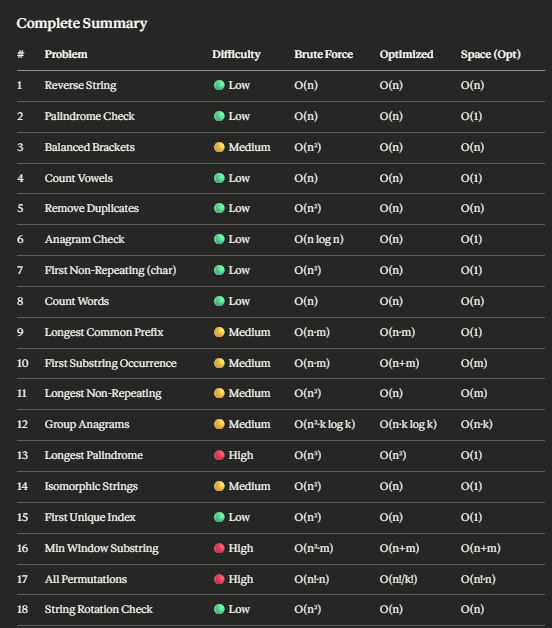